# V2 清洗后早期 EDA / Early EDA After V2 Cleaning

## 1. 设置与读取数据 / Setup and Load Data

读取全部清洗后记录。代码使用英文，说明和结论使用中英双语。 / All cleaned records are loaded. Code is in English, while explanations are bilingual.

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"

DATA_PATH = Path(r"D:\DM1_project\reddit_opinion_climate_change_cleaned_final.csv.gz")
RAW_COMMENT_COUNT = 1_903_836
V1_COMMENT_COUNT = 1_896_017
MIN_WORDS_FOR_CLUSTERING = 5
RANDOM_STATE = 42

count_formatter = FuncFormatter(lambda x, pos: f"{int(x):,}")

df = pd.read_csv(DATA_PATH, compression="gzip", low_memory=False)
for column in ["created_time", "post_created_time", "user_account_created_time"]:
    df[column] = pd.to_datetime(df[column], errors="coerce")

post_df = df.drop_duplicates("post_id").copy()
valid_author_mask = ~df["author_name"].astype(str).str.lower().isin(
    ["[deleted]", "[removed]", "automoderator", "none", "nan"]
)

print("Loaded:", f"{len(df):,}", "comments")
print("Columns:", df.shape[1])
print("File:", DATA_PATH)

Loaded: 1,894,876 comments
Columns: 29
File: D:\DM1_project\reddit_opinion_climate_change_cleaned_final.csv.gz


结果应显示第二轮清洗后保留的完整评论数。后续所有总体统计都来自 V2 文件。 / The result should show the complete number of comments retained after the second cleaning pass. All statistics below use the V2 file.

In [4]:
column_summary = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str).values,
    "non_missing": df.notna().sum().values,
    "missing": df.isna().sum().values,
    "missing_percent": (df.isna().mean() * 100).round(3).values,
    "unique_values": df.nunique(dropna=False).values
})

display(column_summary)

,column_name,data_type,non_missing,missing,missing_percent,unique_values
0,comment_id,object,1894876,0,0.00,1894876
1,score,int64,1894876,0,0.00,2585
2,self_text,object,1894876,0,0.00,1861239
3,subreddit,object,1894876,0,0.00,26
4,created_time,datetime64[ns],1894876,0,0.00,1869019
5,post_id,object,1894876,0,0.00,61494
6,author_name,object,1894876,0,0.00,410882
7,controversiality,int64,1894876,0,0.00,2
8,ups,int64,1894876,0,0.00,2585
9,downs,int64,1894876,0,0.00,1


## 2. 清洗效果与数据层级 / Cleaning Audit and Units of Analysis

In [19]:
cleaning_audit = pd.DataFrame({
    "metric": [
        "Raw comments", 
        "Total removed", "Overall retention rate",
        "Unique posts", "Unique author labels", "Valid named authors", "Subreddits",
        "Earliest comment", "Latest comment"
    ],
    "value": [
        f"{RAW_COMMENT_COUNT:,}", 
        f"{RAW_COMMENT_COUNT-len(df):,}",
        f"{len(df)/RAW_COMMENT_COUNT:.2%}", f"{df['post_id'].nunique():,}",
        f"{df['author_name'].nunique():,}",
        f"{df.loc[valid_author_mask, 'author_name'].nunique():,}",
        f"{df['subreddit'].nunique():,}", str(df['created_time'].min()),
        str(df['created_time'].max())
    ]
})
cleaning_audit

,metric,value
0,Raw comments,"1,903,836"
1,Total removed,"8,960"
2,Overall retention rate,99.53%
3,Unique posts,"61,494"
4,Unique author labels,"410,882"
5,Valid named authors,"410,881"
6,Subreddits,26
7,Earliest comment,2018-06-01 00:40:15
8,Latest comment,2026-09-18 07:08:09


评论、帖子和用户名称是三个不同层级。删除数量反映清洗规则移除的记录，不应解释为全部都是被 Reddit 删除的评论。 / Comments, posts, and author labels are different units. Removed rows reflect the cleaning rules and are not all necessarily Reddit-deleted comments.

## 3. 清洗后完整性检查 / Post-Cleaning Integrity Checks

In [20]:
lower_text = df["clean_text"].fillna("").str.strip().str.lower()
moderation_author = df["author_name"].fillna("").str.lower().str.contains(
    r"automoderator|modteam|read-the-rules|ukbot|revddit", regex=True
)
residual_target_notice = moderation_author & lower_text.str.contains(
    r"removed|breaking\s+rule|reviewing\s+removed\s+content", regex=True, na=False
)
integrity_checks = pd.DataFrame({
    "check": [
        "Duplicate comment IDs", "Missing clean_text", "Empty clean_text",
        "Exact [deleted] or [removed] text", "Targeted moderation templates",
        "Duplicate full rows", "score equals ups", "post_score equals post_thumbs_ups",
        "downs unique values", "post awards unique values"
    ],
    "result": [
        int(df["comment_id"].duplicated().sum()), int(df["clean_text"].isna().sum()),
        int(lower_text.eq("").sum()), int(lower_text.isin(["[deleted]", "[removed]"]).sum()),
        int(residual_target_notice.sum()),
        int(df.duplicated().sum()), bool(df["score"].equals(df["ups"])),
        bool(df["post_score"].equals(df["post_thumbs_ups"])),
        int(df["downs"].nunique(dropna=False)),
        int(df["post_total_awards_received"].nunique(dropna=False))
    ]
})
integrity_checks

,check,result
0,Duplicate comment IDs,0
1,Missing clean_text,0
2,Empty clean_text,0
3,Exact [deleted] or [removed] text,0
4,Targeted moderation templates,0
5,Duplicate full rows,0
6,score equals ups,True
7,post_score equals post_thumbs_ups,True
8,downs unique values,1
9,post awards unique values,1


V2 验证目标是评论 ID 无重复、清洗文本不为空、删除占位符和目标审核模板为零。重复字段与常量字段继续保留用于追溯，但不应同时进入未来模型。 / V2 validation requires unique comment IDs, non-empty cleaned text, and zero targeted deletion placeholders or moderation templates. Redundant and constant fields remain only for traceability.

## 4. 清洗后缺失值 / Missing Values After Cleaning

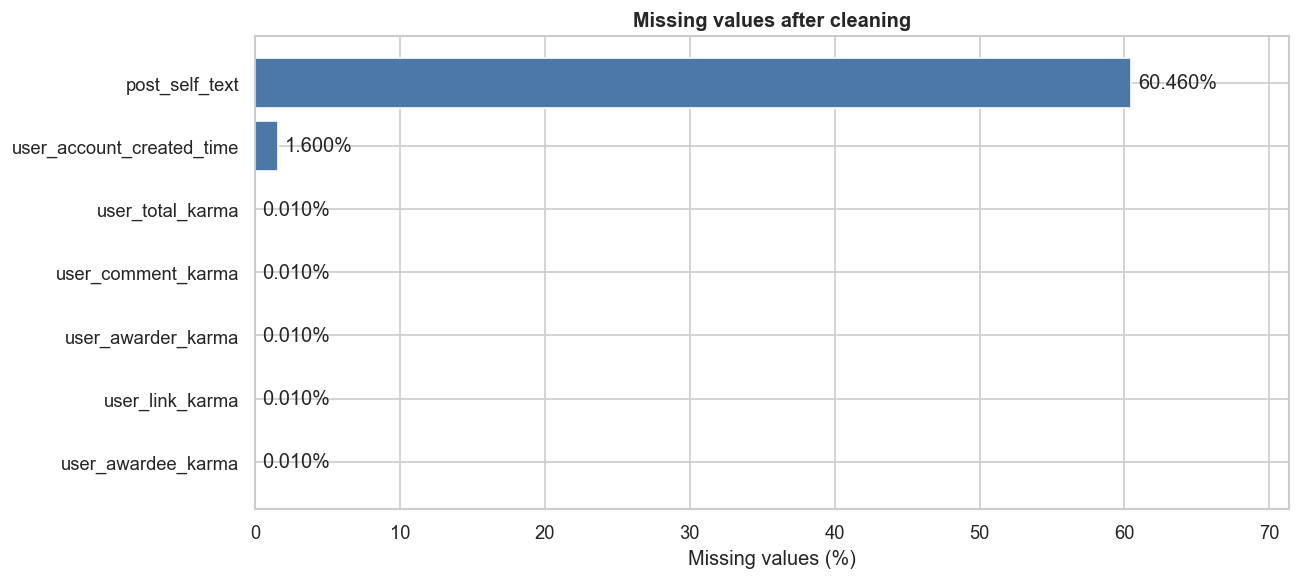

,missing_percentage
post_self_text,60.459629
user_account_created_time,1.599946
user_awardee_karma,0.009658
user_awarder_karma,0.009658
user_link_karma,0.009658
user_total_karma,0.009658
user_comment_karma,0.009658


In [4]:
missing = df.isna().mean().mul(100).sort_values()
missing_nonzero = missing[missing.gt(0)]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(missing_nonzero.index, missing_nonzero.values, color="#4C78A8")
ax.set_title("Missing values after cleaning")
ax.set_xlabel("Missing values (%)")
ax.bar_label(bars, labels=[f"{v:.3f}%" for v in missing_nonzero], padding=4)
ax.set_xlim(0, max(1, missing_nonzero.max() * 1.18))
plt.tight_layout()
plt.show()

missing_nonzero.sort_values(ascending=False).to_frame("missing_percentage")

缺失值需要按字段含义解释。`post_self_text` 为空不等于帖子被删除；用户 karma 缺失应保持未知，而不是填 0。 / Missingness depends on field meaning. Missing post body text does not imply deletion, and missing user karma should remain unknown rather than being replaced by zero.

## 5. Subreddit 规模、份额与集中度 / Subreddit Size, Share, and Concentration

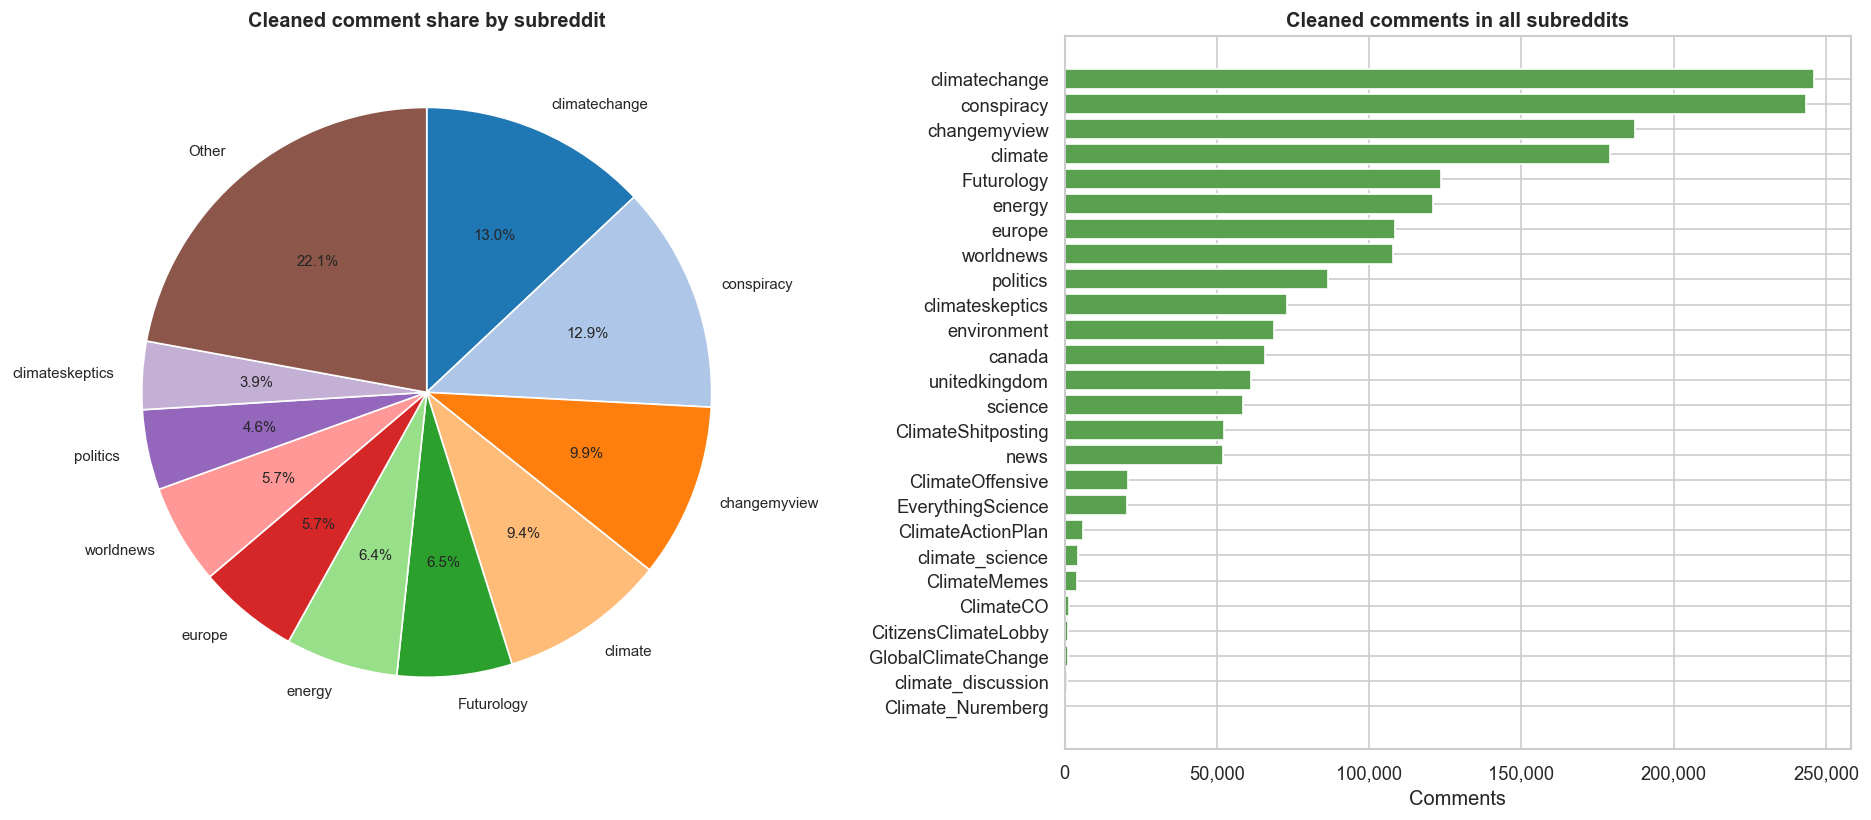

,metric,value
0,Largest subreddit share,0.129784
1,Top 5 share,0.516789
2,Top 10 share,0.778817
3,HHI,0.076742
4,Effective subreddit count,13.030721


In [5]:
subreddit_counts = df["subreddit"].value_counts()
subreddit_share = subreddit_counts / len(df)
top10 = subreddit_counts.head(10).copy()
top10.loc["Other"] = subreddit_counts.iloc[10:].sum()

hhi = float((subreddit_share ** 2).sum())
effective_subreddits = 1 / hhi

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].pie(
    top10.values, labels=top10.index,
    autopct=lambda p: f"{p:.1f}%" if p >= 2 else "",
    startangle=90, counterclock=False,
    colors=sns.color_palette("tab20", len(top10)), textprops={"fontsize": 9}
)
axes[0].set_title("Cleaned comment share by subreddit")

bar_data = subreddit_counts.sort_values()
axes[1].barh(bar_data.index, bar_data.values, color="#59A14F")
axes[1].set_title("Cleaned comments in all subreddits")
axes[1].set_xlabel("Comments")
axes[1].xaxis.set_major_formatter(count_formatter)
plt.tight_layout()
plt.show()

pd.DataFrame({
    "metric": ["Largest subreddit share", "Top 5 share", "Top 10 share", "HHI", "Effective subreddit count"],
    "value": [subreddit_share.iloc[0], subreddit_share.head(5).sum(), subreddit_share.head(10).sum(), hhi, effective_subreddits]
})

HHI 越高表示数据越集中；`1/HHI` 可理解为当前不平衡程度相当于多少个同规模社区。该指标用于判断是否需要分层抽样。 / A higher HHI means greater concentration. `1/HHI` is the equivalent number of equally sized communities and helps determine whether stratified sampling is needed.

## 6. 争议性及不确定区间 / Controversiality and Uncertainty Intervals

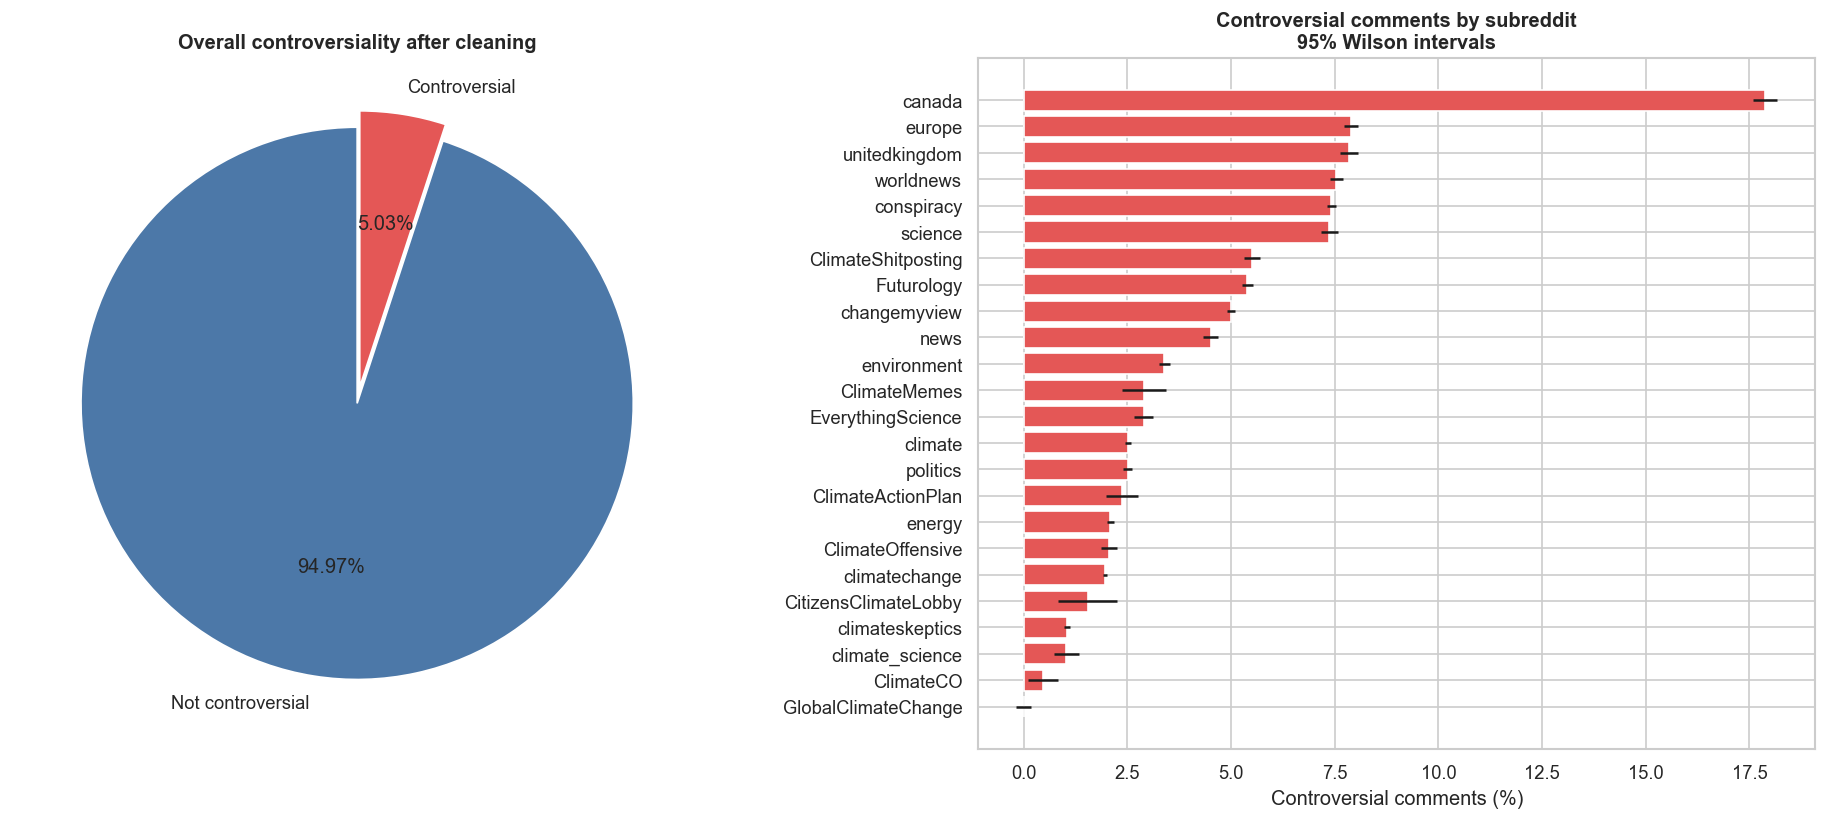

,comments,controversial,rate,ci_low,ci_high
subreddit,,,,,
canada,65702,11746,0.178777,0.175866,0.181726
europe,108501,8565,0.078939,0.077350,0.080559
unitedkingdom,61057,4789,0.078435,0.076329,0.080594
worldnews,107716,8123,0.075411,0.073849,0.077003
conspiracy,243531,18059,0.074155,0.073121,0.075202
science,58739,4331,0.073733,0.071647,0.075874
ClimateShitposting,52227,2879,0.055125,0.053200,0.057115
Futurology,123555,6668,0.053968,0.052722,0.055242
changemyview,187214,9350,0.049943,0.048965,0.050939


In [6]:
controversy = (
    df.groupby("subreddit")
    .agg(comments=("comment_id", "size"), controversial=("controversiality", "sum"))
)
controversy["rate"] = controversy["controversial"] / controversy["comments"]
z = 1.96
n = controversy["comments"]
p = controversy["rate"]
denom = 1 + z**2/n
center = (p + z**2/(2*n)) / denom
half = z * np.sqrt((p*(1-p) + z**2/(4*n))/n) / denom
controversy["ci_low"] = center - half
controversy["ci_high"] = center + half
controversy = controversy.query("comments >= 1000").sort_values("rate")

overall_rate = df["controversiality"].mean()
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].pie(
    [1-overall_rate, overall_rate], labels=["Not controversial", "Controversial"],
    autopct="%1.2f%%", startangle=90, colors=["#4C78A8", "#E45756"], explode=[0, .06]
)
axes[0].set_title("Overall controversiality after cleaning")

axes[1].barh(controversy.index, controversy["rate"]*100, color="#E45756", xerr=half.loc[controversy.index]*100)
axes[1].set_title("Controversial comments by subreddit\n95% Wilson intervals")
axes[1].set_xlabel("Controversial comments (%)")
plt.tight_layout()
plt.show()

controversy.sort_values("rate", ascending=False).head(10)

误差线是 95% Wilson 区间：样本越少，区间通常越宽。社区之间的差异是关联结果，不能解释为社区导致争议。 / Error bars are 95% Wilson intervals and are generally wider for smaller samples. Differences are associations, not evidence that a community causes controversy.

## 7. 评论得分：正分、零分与负分 / Comment Scores: Positive, Zero, and Negative

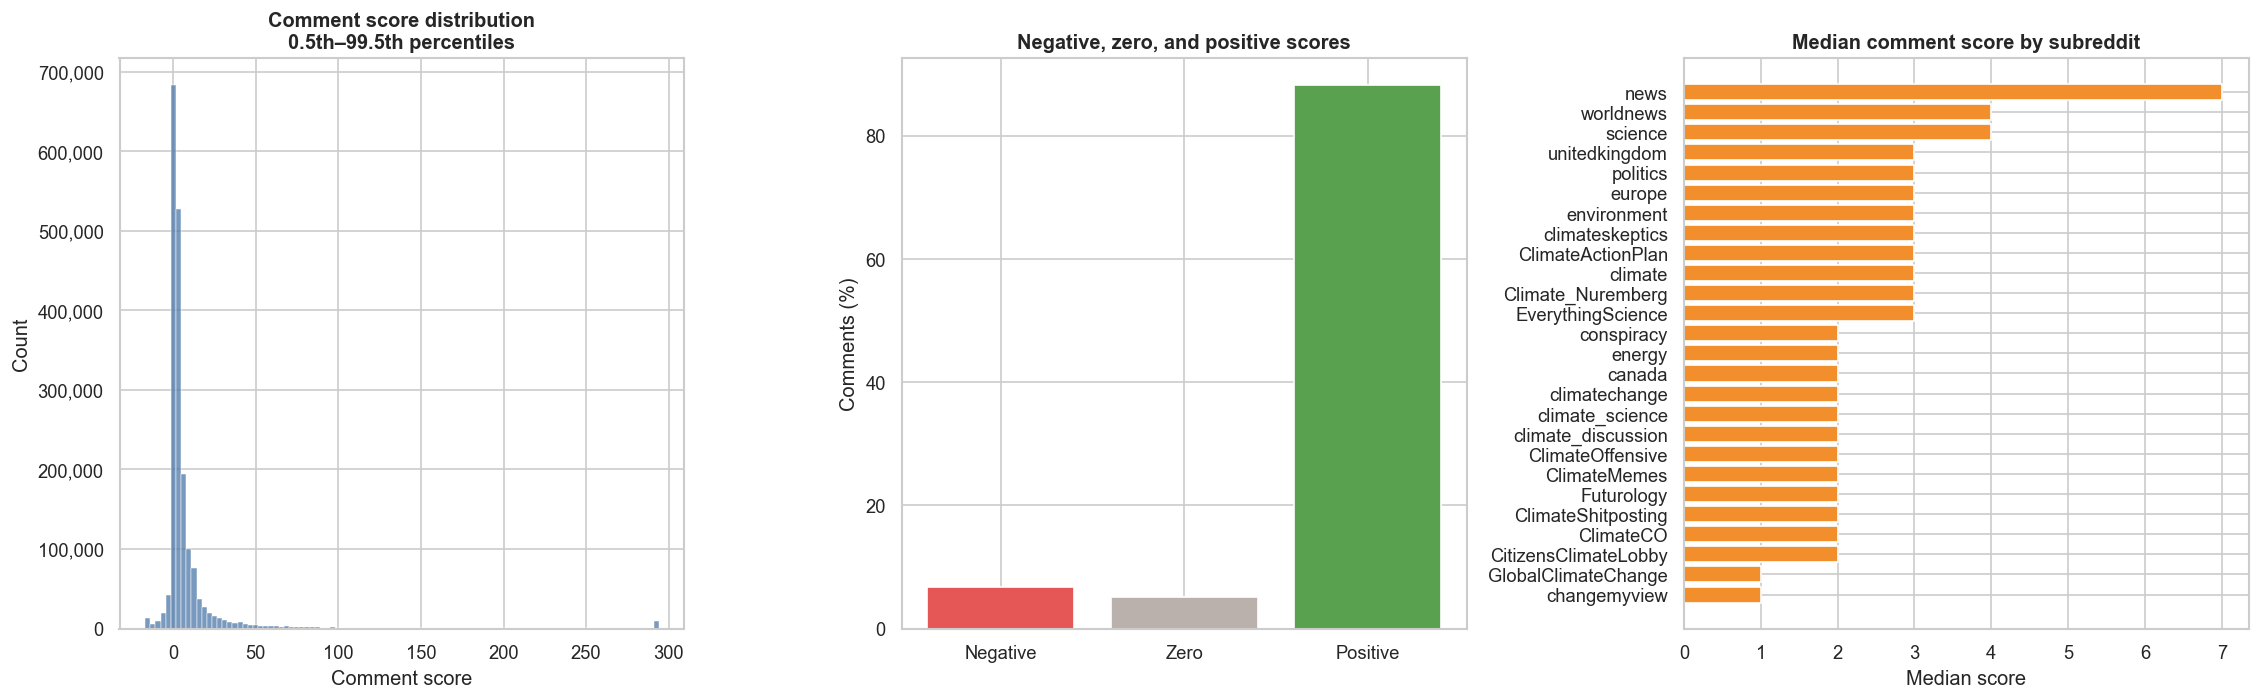

,share
score,
Negative,0.06682
Zero,0.05168
Positive,0.88150


,count,mean,median,min,max
controversiality,,,,,
0,1799551,12.578790,2.0,-659,29564
1,95325,1.167679,1.0,-103,385


In [7]:
score_category = pd.cut(
    df["score"], bins=[-np.inf, -1, 0, np.inf],
    labels=["Negative", "Zero", "Positive"]
)
score_category_share = score_category.value_counts(normalize=True).reindex(["Negative", "Zero", "Positive"])
low, high = df["score"].quantile([.005, .995])

score_by_subreddit = (
    df.assign(negative=df["score"].lt(0), positive=df["score"].gt(0))
    .groupby("subreddit")
    .agg(comments=("comment_id", "size"), median_score=("score", "median"),
         negative_share=("negative", "mean"), positive_share=("positive", "mean"))
    .sort_values("median_score")
)

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
sns.histplot(df["score"].clip(low, high), bins=100, ax=axes[0], color="#4C78A8")
axes[0].set_title("Comment score distribution\n0.5th–99.5th percentiles")
axes[0].set_xlabel("Comment score")
axes[0].yaxis.set_major_formatter(count_formatter)

axes[1].bar(score_category_share.index, score_category_share.values*100, color=["#E45756", "#BAB0AC", "#59A14F"])
axes[1].set_title("Negative, zero, and positive scores")
axes[1].set_ylabel("Comments (%)")

axes[2].barh(score_by_subreddit.index, score_by_subreddit["median_score"], color="#F28E2B")
axes[2].set_title("Median comment score by subreddit")
axes[2].set_xlabel("Median score")
plt.tight_layout()
plt.show()

display(score_category_share.to_frame("share"))
df.groupby("controversiality")["score"].agg(
    count="count", mean="mean", median="median", min="min", max="max"
)

负分表示净反对票多于净赞成票，但不等同于 controversial。截断只影响绘图，不改变表格中的原始最低和最高分。 / A negative score means net downvotes exceed net upvotes, but it is not the same as controversiality. Clipping affects only the plot, not the original minima and maxima in the table.

## 8. 帖子层面的互动与赞成比例 / Post-Level Engagement and Upvote Ratio

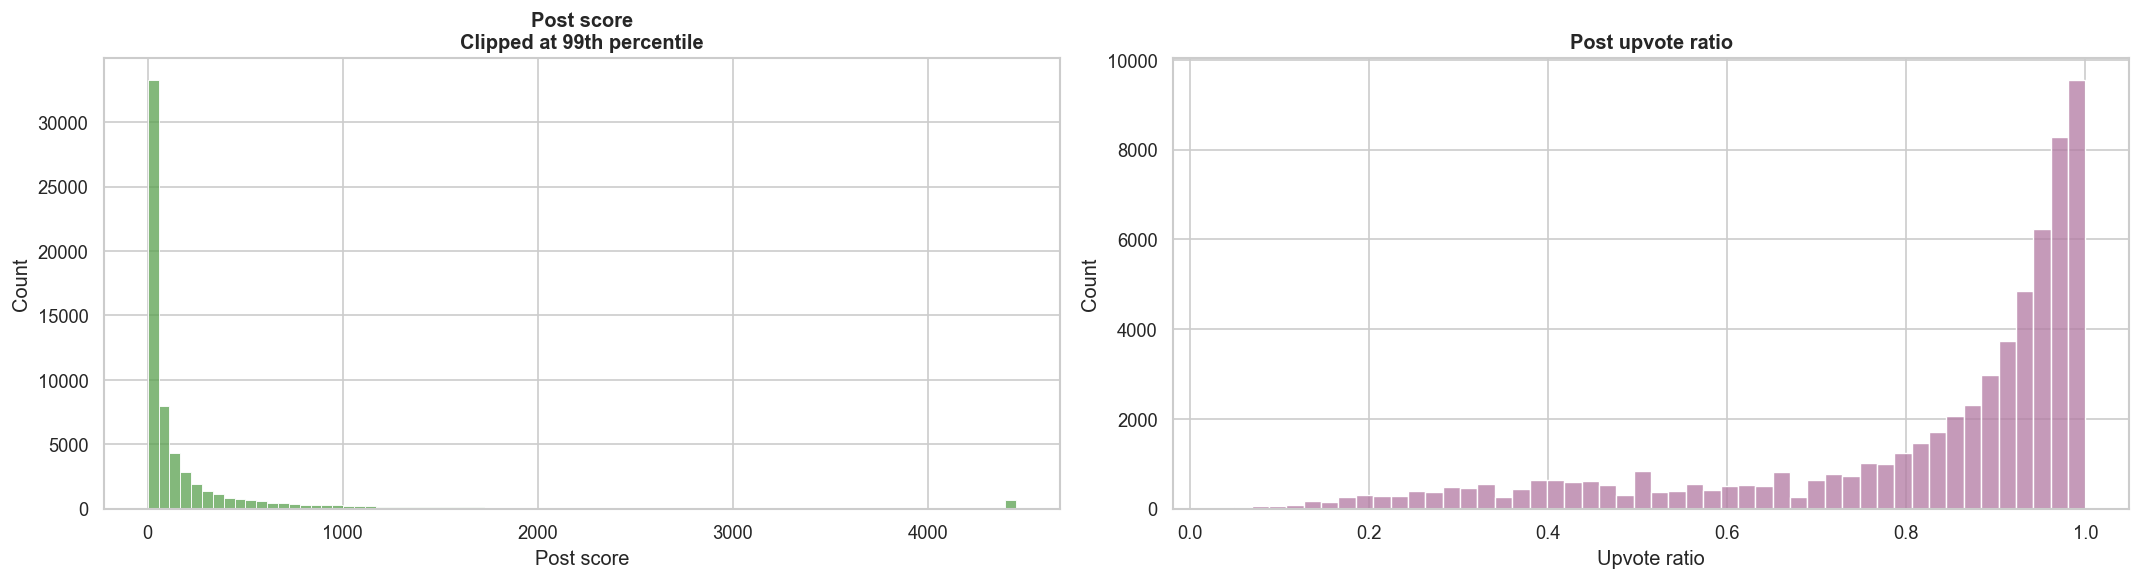

,count,mean,std,min,25%,50%,75%,max
post_score,61494.0,300.241796,1302.851552,0.00,9.00,45.00,175.00,61246.0
post_upvote_ratio,61494.0,0.816854,0.220471,0.03,0.75,0.92,0.97,1.0


In [7]:
post_cap = post_df["post_score"].quantile(.99)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.histplot(post_df["post_score"].clip(upper=post_cap), bins=80, ax=axes[0], color="#59A14F")
axes[0].set_title("Post score\nClipped at 99th percentile")
axes[0].set_xlabel("Post score")

sns.histplot(post_df["post_upvote_ratio"], bins=50, ax=axes[1], color="#B279A2")
axes[1].set_title("Post upvote ratio")
axes[1].set_xlabel("Upvote ratio")

plt.tight_layout()
plt.show()

post_df[["post_score", "post_upvote_ratio"]].describe().T

`downs=0` 不表示没有点踩；该字段没有提供有效点踩数。`post_upvote_ratio` 是 Reddit 单独提供的比例，而 `post_score` 是净得分。 / `downs=0` does not mean there were no downvotes; that field is uninformative. `post_upvote_ratio` is a separate Reddit-provided ratio, while `post_score` is a net score.

## 9. 帖子正文可用性 / Post Body Availability

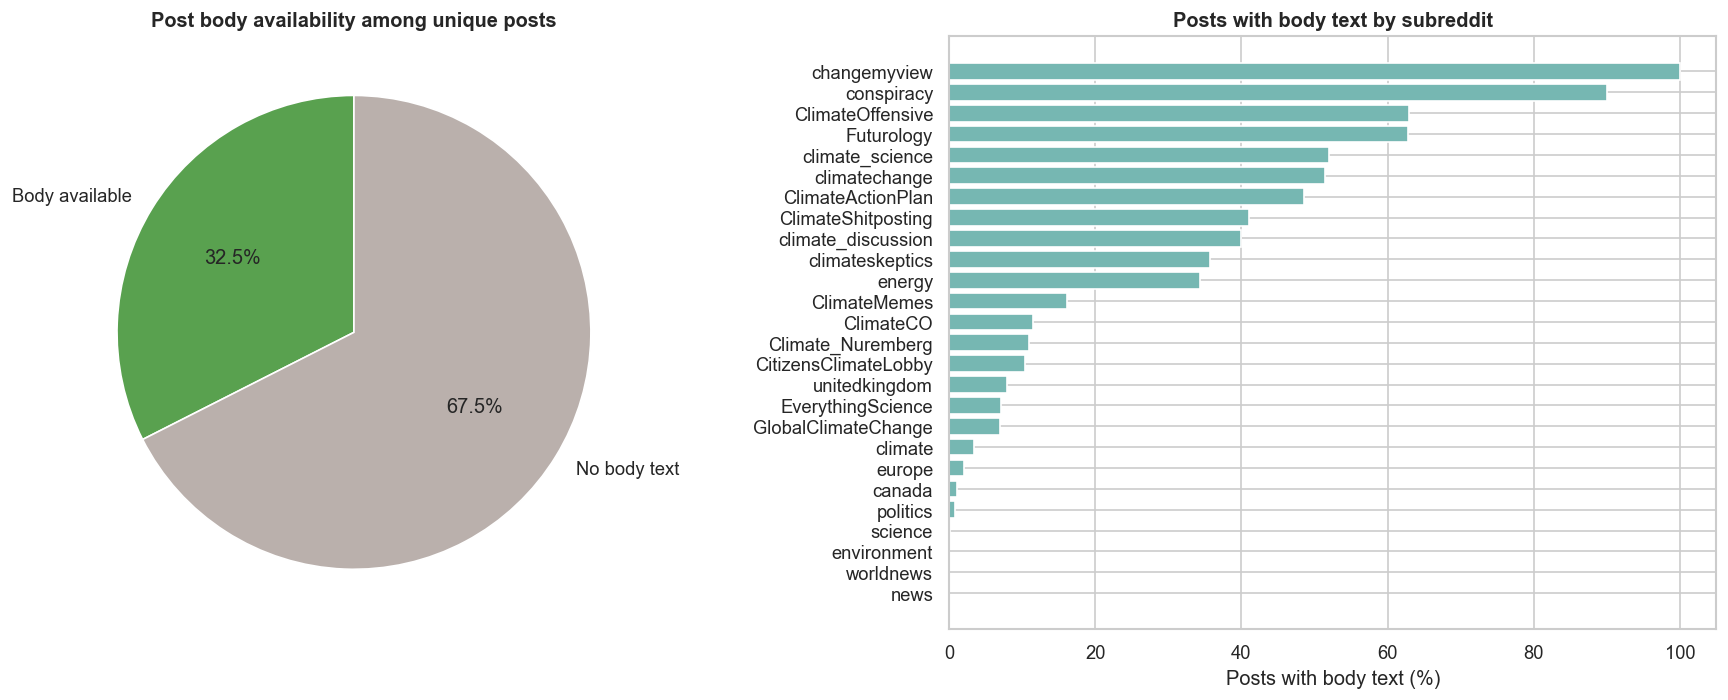

,unique_posts
Body available,19966
No body text,41528


In [9]:
post_body = post_df["has_post_self_text"].value_counts().reindex([True, False], fill_value=0)
post_body.index = ["Body available", "No body text"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].pie(post_body.values, labels=post_body.index, autopct="%1.1f%%", startangle=90,
            colors=["#59A14F", "#BAB0AC"])
axes[0].set_title("Post body availability among unique posts")

body_by_subreddit = post_df.groupby("subreddit")["has_post_self_text"].mean().sort_values()
axes[1].barh(body_by_subreddit.index, body_by_subreddit.values*100, color="#76B7B2")
axes[1].set_title("Posts with body text by subreddit")
axes[1].set_xlabel("Posts with body text (%)")
plt.tight_layout()
plt.show()

post_body.to_frame("unique_posts")

社区之间的正文可用率可帮助判断其帖子类型差异，但没有正文仍不能自动解释为删帖。 / Differences in body availability help reveal posting-format differences, but absence of body text still does not automatically imply deletion.

## 10. 清洗后文本长度与聚类可用性 / Cleaned Text Length and Clustering Eligibility

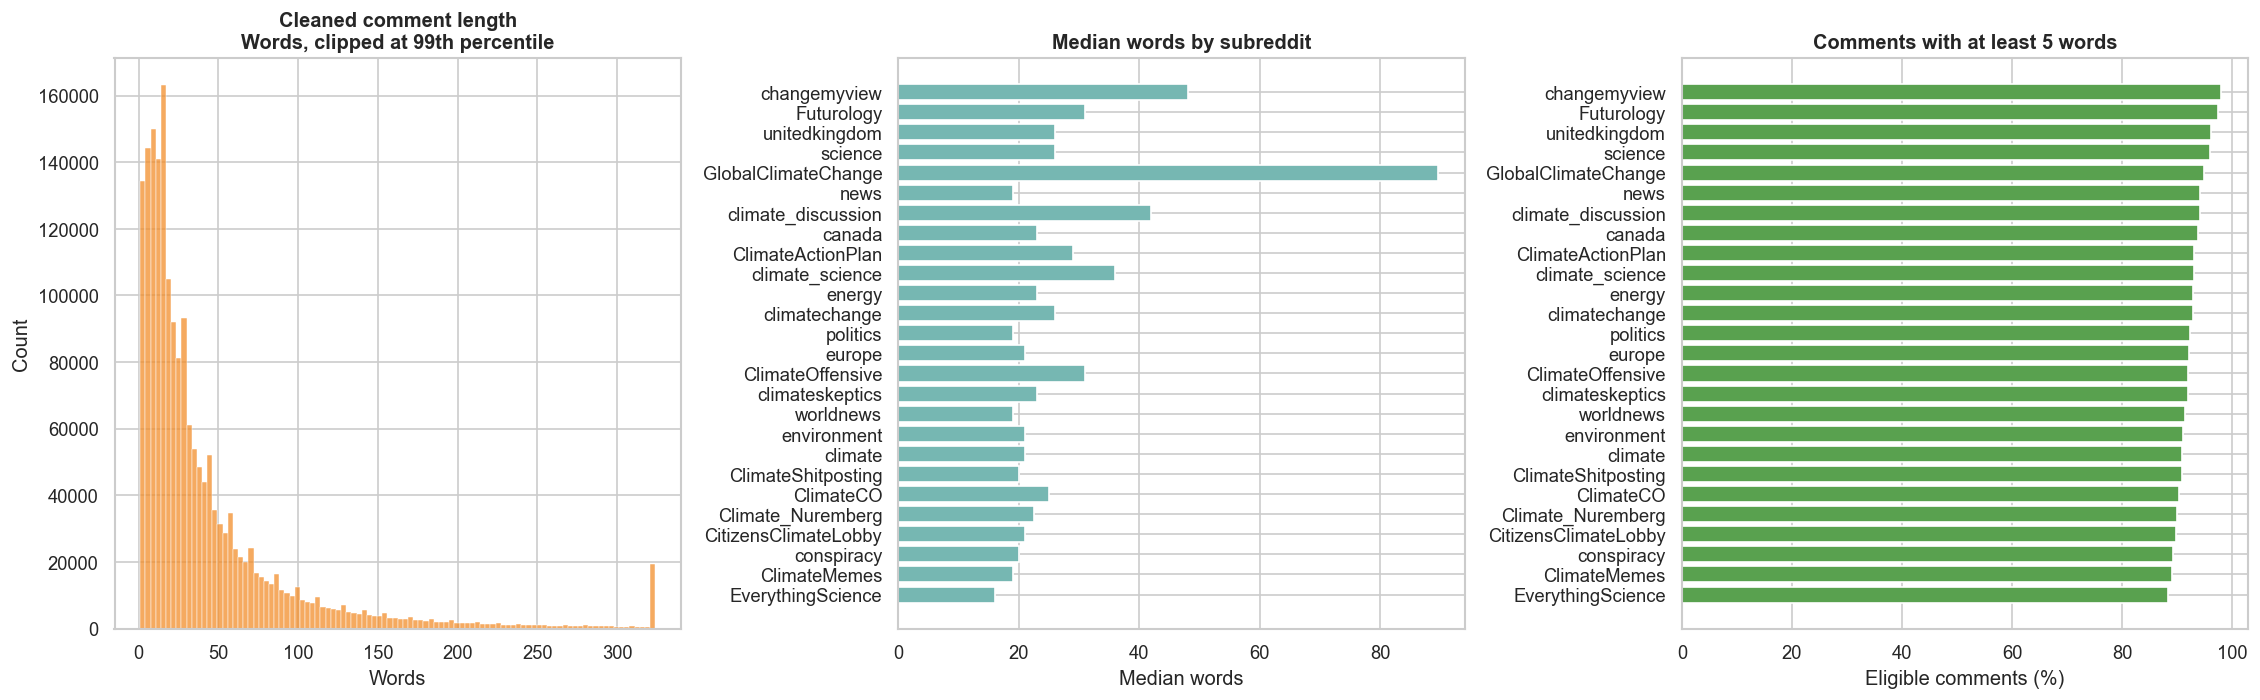

,category,comments,share
0,Eligible for clustering,1760461,0.929064
1,Below 5 words,134415,0.070936


In [10]:
eligible = df["comment_word_count"].ge(MIN_WORDS_FOR_CLUSTERING)
eligibility_by_subreddit = (
    df.assign(eligible=eligible)
    .groupby("subreddit")
    .agg(comments=("comment_id", "size"), median_words=("comment_word_count", "median"),
         median_chars=("comment_char_count", "median"), eligible_rate=("eligible", "mean"))
    .sort_values("eligible_rate")
)

word_cap = df["comment_word_count"].quantile(.99)
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
sns.histplot(df["comment_word_count"].clip(upper=word_cap), bins=100, ax=axes[0], color="#F28E2B")
axes[0].set_title("Cleaned comment length\nWords, clipped at 99th percentile")
axes[0].set_xlabel("Words")

axes[1].barh(eligibility_by_subreddit.index, eligibility_by_subreddit["median_words"], color="#76B7B2")
axes[1].set_title("Median words by subreddit")
axes[1].set_xlabel("Median words")

axes[2].barh(eligibility_by_subreddit.index, eligibility_by_subreddit["eligible_rate"]*100, color="#59A14F")
axes[2].set_title(f"Comments with at least {MIN_WORDS_FOR_CLUSTERING} words")
axes[2].set_xlabel("Eligible comments (%)")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "category": ["Eligible for clustering", "Below 5 words"],
    "comments": [int(eligible.sum()), int((~eligible).sum())],
    "share": [eligible.mean(), (~eligible).mean()]
})

词数比字符数更接近文本信息量。至少 5 个词是聚类准入规则，不表示较短评论是无效数据；它们仍可用于得分或争议性统计。 / Word count better reflects textual information. The five-word threshold is for clustering eligibility, not a claim that shorter comments are invalid for all analyses.

## 11. 时间覆盖与月度变化 / Time Coverage and Monthly Trends

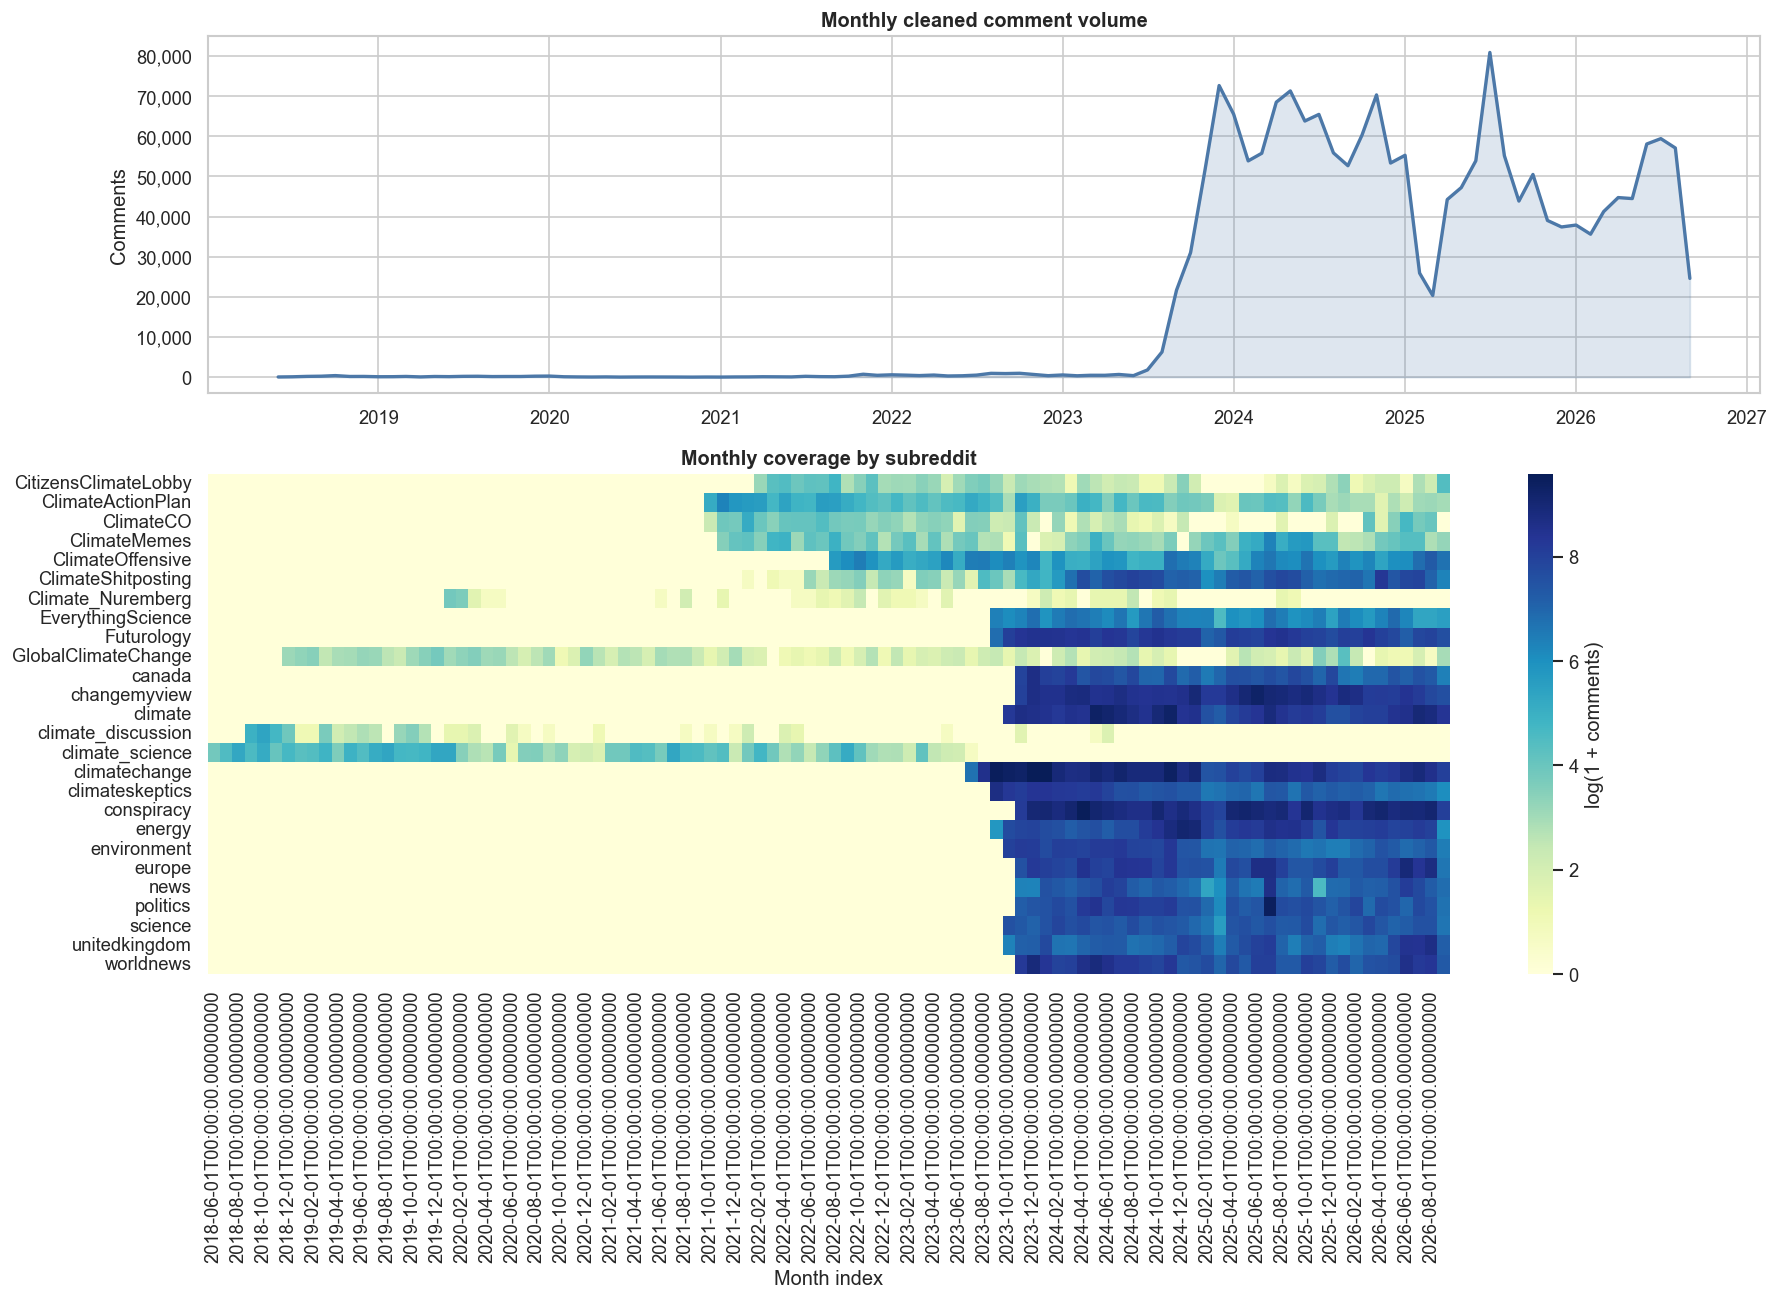

,start,end,comments,coverage_days
subreddit,,,,
climate_science,2018-06-01 00:40:15,2023-07-13 01:40:54,4264,1868
climate_discussion,2018-09-18 16:38:59,2024-06-27 16:46:34,725,2109
GlobalClimateChange,2018-12-10 17:14:20,2026-09-17 21:51:29,1064,2838
Climate_Nuremberg,2020-01-08 23:51:32,2025-09-09 15:02:49,178,2070
ClimateActionPlan,2021-10-10 23:38:46,2026-09-15 00:40:04,6057,1800
ClimateCO,2021-10-26 23:56:09,2026-08-31 13:57:11,1498,1769
ClimateMemes,2021-11-16 03:02:51,2026-09-03 00:04:34,4034,1751
ClimateShitposting,2022-01-28 22:07:57,2026-09-18 05:21:46,52227,1693
CitizensClimateLobby,2022-02-16 18:19:27,2026-09-10 00:34:33,1231,1666


In [11]:
coverage = df.groupby("subreddit")["created_time"].agg(start="min", end="max", comments="size")
coverage["coverage_days"] = (coverage["end"] - coverage["start"]).dt.days
monthly = df.set_index("created_time").resample("MS").size()

monthly_matrix = (
    df.groupby([pd.Grouper(key="created_time", freq="MS"), "subreddit"])
    .size().unstack(fill_value=0)
)
monthly_share = monthly_matrix.div(monthly_matrix.sum(axis=0).replace(0, np.nan), axis=1)

fig, axes = plt.subplots(2, 1, figsize=(15, 11), gridspec_kw={"height_ratios": [1, 1.4]})
axes[0].plot(monthly.index, monthly.values, color="#4C78A8", linewidth=2)
axes[0].fill_between(monthly.index, monthly.values, alpha=.18, color="#4C78A8")
axes[0].set_title("Monthly cleaned comment volume")
axes[0].set_ylabel("Comments")
axes[0].yaxis.set_major_formatter(count_formatter)

sns.heatmap(np.log1p(monthly_matrix.T), cmap="YlGnBu", ax=axes[1], cbar_kws={"label": "log(1 + comments)"})
axes[1].set_title("Monthly coverage by subreddit")
axes[1].set_xlabel("Month index")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

coverage.sort_values("start")

热图重点不是比较绝对颜色，而是检查每个社区从何时开始被覆盖、是否存在中断。社区比较应使用共同时间窗口或按月分层。 / The heatmap is mainly for checking when each community enters the dataset and whether gaps exist. Community comparisons should use a common window or month stratification.

## 12. 评论者活跃度、集中度与 Lorenz 曲线 / Commenter Activity, Concentration, and Lorenz Curve

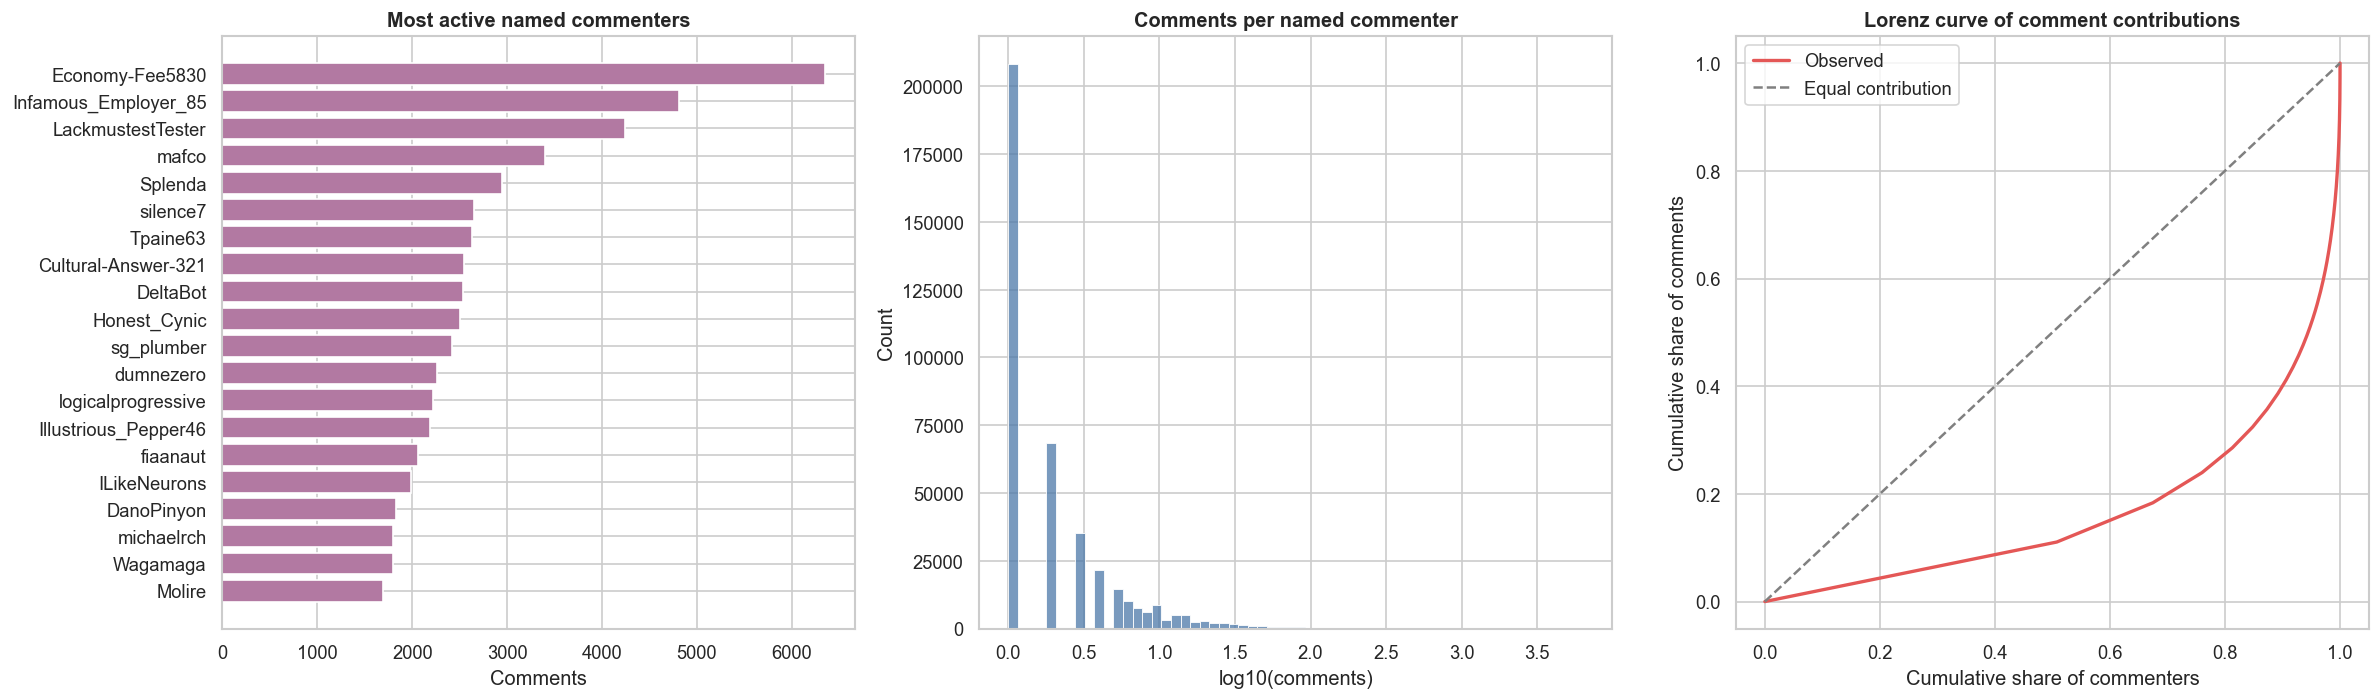

,metric,value
0,Named commenters,410881.000000
1,Median comments,1.000000
2,99th percentile,48.000000
3,Maximum,6350.000000
4,Top 1% comment share,0.270911
5,Gini coefficient,0.662556


In [12]:
author_counts = df.loc[valid_author_mask, "author_name"].value_counts()
sorted_counts = np.sort(author_counts.values)
cum_comments = np.cumsum(sorted_counts) / sorted_counts.sum()
cum_authors = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
gini = 1 - 2 * np.trapezoid(cum_comments, cum_authors)

def top_share(values, fraction):
    values = np.sort(np.asarray(values))[::-1]
    n_top = max(1, int(np.ceil(len(values) * fraction)))
    return values[:n_top].sum() / values.sum()

top_authors = author_counts.head(20).sort_values()
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].barh(top_authors.index, top_authors.values, color="#B279A2")
axes[0].set_title("Most active named commenters")
axes[0].set_xlabel("Comments")

sns.histplot(np.log10(author_counts.values), bins=60, ax=axes[1], color="#4C78A8")
axes[1].set_title("Comments per named commenter")
axes[1].set_xlabel("log10(comments)")

axes[2].plot(cum_authors, cum_comments, color="#E45756", linewidth=2, label="Observed")
axes[2].plot([0,1], [0,1], linestyle="--", color="gray", label="Equal contribution")
axes[2].set_title("Lorenz curve of comment contributions")
axes[2].set_xlabel("Cumulative share of commenters")
axes[2].set_ylabel("Cumulative share of comments")
axes[2].legend()
plt.tight_layout()
plt.show()

pd.DataFrame({
    "metric": ["Named commenters", "Median comments", "99th percentile", "Maximum", "Top 1% comment share", "Gini coefficient"],
    "value": [len(author_counts), author_counts.median(), author_counts.quantile(.99), author_counts.max(), top_share(author_counts, .01), gini]
})

Lorenz 曲线离对角线越远、Gini 越高，说明评论越集中在少数活跃用户手中。这里排除了 `[deleted]` 等占位名称。 / The farther the Lorenz curve is from equality and the higher the Gini, the more comments are concentrated among a few active users. Placeholder authors such as `[deleted]` are excluded.

## 13. 帖子讨论量与单帖主导程度 / Discussion Size and Post Dominance

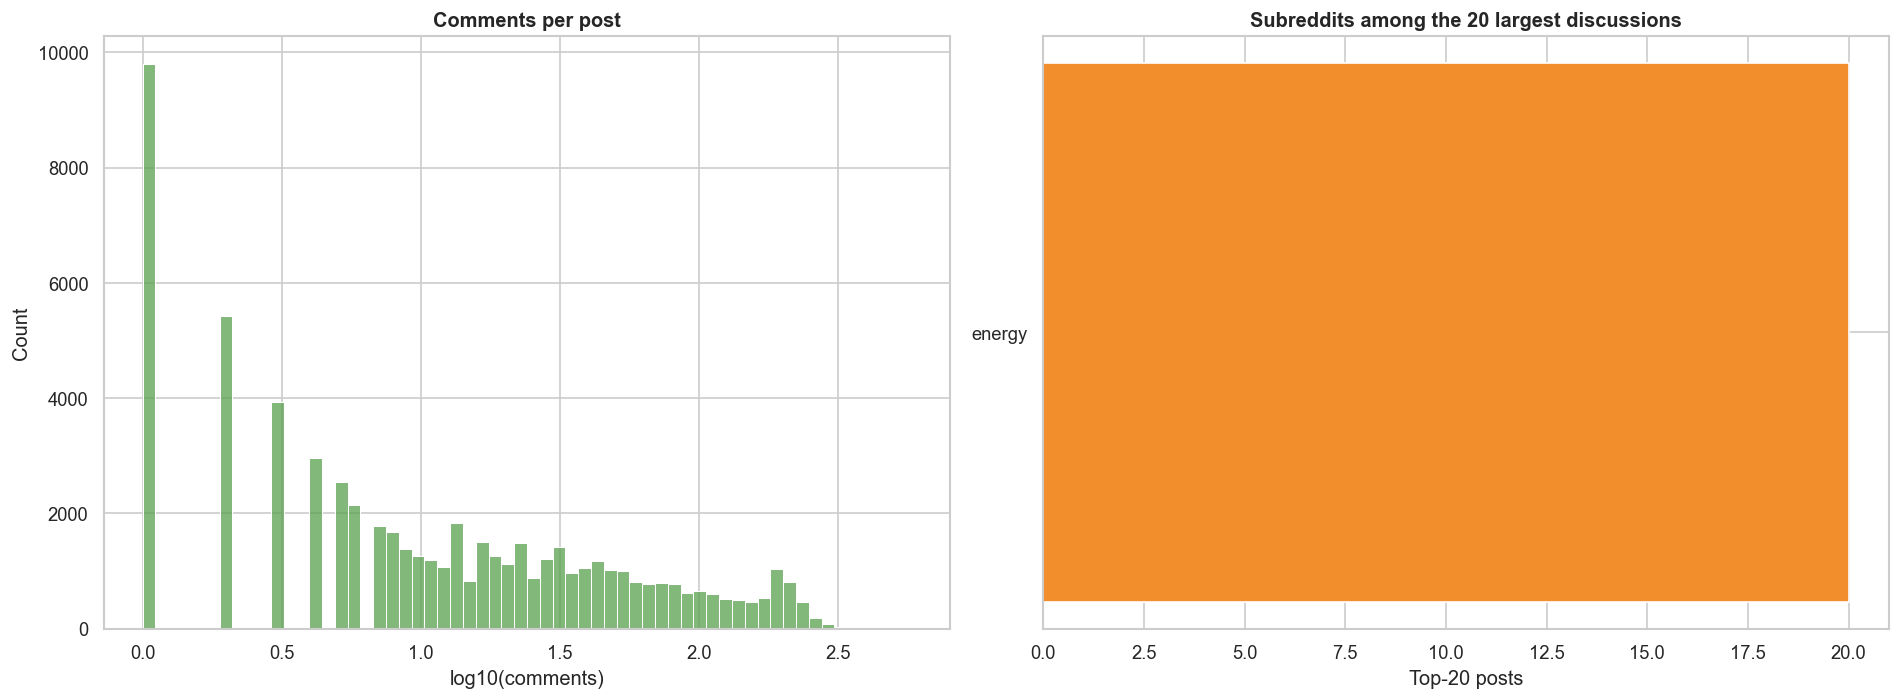

,metric,value
0,Posts,61494.00000
1,Median comments per post,9.00000
2,95th percentile,165.00000
3,99th percentile,231.00000
4,Maximum,581.00000
5,Top 1% comment share,0.08814


,post_title,subreddit,comment_count
post_id,,,
1e5luu1,Why does the RNC seem to think we don’t produc...,energy,581
1vj1tht,Your gas car works fine. Consider an EV anyway...,energy,564
1hgdq4j,Trump transition team has fleshed out its plan...,energy,559
1h8cy4d,Biden’s $1 trillion investment in clean energy...,energy,557
1gy30u0,Automakers to Trump: Please Require Us to Sell...,energy,555
1gzk2uf,Trump Picks Climate-Denying Oil &amp; Gas Magn...,energy,547
1unh2mh,Mamdani mocked by GOP for telling New Yorkers ...,energy,546
1hjyyhf,Trump aims at Biden's Inflation Reduction Act:...,energy,545
1hgebzi,Biden’s EV Battery Boom Is Coming — Whether Tr...,energy,505


In [13]:
comments_per_post = df.groupby("post_id").size()
post_concentration = pd.DataFrame({
    "metric": ["Posts", "Median comments per post", "95th percentile", "99th percentile", "Maximum", "Top 1% comment share"],
    "value": [len(comments_per_post), comments_per_post.median(), comments_per_post.quantile(.95),
              comments_per_post.quantile(.99), comments_per_post.max(), top_share(comments_per_post, .01)]
})
top_posts = (
    post_df.set_index("post_id")[["post_title", "subreddit"]]
    .join(comments_per_post.rename("comment_count"))
    .sort_values("comment_count", ascending=False)
    .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(np.log10(comments_per_post.values), bins=60, ax=axes[0], color="#59A14F")
axes[0].set_title("Comments per post")
axes[0].set_xlabel("log10(comments)")

top_post_subreddits = top_posts["subreddit"].value_counts().sort_values()
axes[1].barh(top_post_subreddits.index, top_post_subreddits.values, color="#F28E2B")
axes[1].set_title("Subreddits among the 20 largest discussions")
axes[1].set_xlabel("Top-20 posts")
plt.tight_layout()
plt.show()

display(post_concentration)
top_posts

若前 20 个大型讨论仍集中于单一社区，且最大评论数集中在相似上限附近，应检查采集上限或抽样规则。 / If the largest discussions remain concentrated in one community and maxima cluster near a similar ceiling, collection caps or sampling rules should be investigated.

## 14. 清洗后重复文本 / Repeated Text After Cleaning

In [14]:
normalized = (
    df["clean_text"].fillna("").astype(str).str.strip().str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"[^\w\s]", "", regex=True)
)
text_counts = normalized[normalized.ne("")].value_counts()
duplicate_rows = int((text_counts - 1).clip(lower=0).sum())

duplicate_summary = pd.DataFrame({
    "metric": ["Unique normalized texts", "Rows beyond first occurrence", "Duplicate-row share", "Texts repeated 10+ times"],
    "value": [len(text_counts), duplicate_rows, duplicate_rows/len(df), int(text_counts.ge(10).sum())]
})
top_repeated = pd.DataFrame({
    "text_preview": [t[:180] for t in text_counts.head(20).index],
    "frequency": text_counts.head(20).values
})
display(duplicate_summary)
top_repeated

,metric,value
0,Unique normalized texts,1.840988e+06
1,Rows beyond first occurrence,5.104800e+04
2,Duplicate-row share,2.694002e-02
3,Texts repeated 10+ times,8.700000e+02


,text_preview,frequency
0,yes,1126
1,no,910
2,lol,863
3,thank you,661
4,exactly,514
5,thanks,422
6,source,393
7,this,385
8,dont look up,378
9,what,335


清洗后仍重复的 `yes/no/lol` 等短回复是真实互动，但不适合主题聚类。是否删除应由分析目的决定，而不是把所有重复文本一律视为垃圾。 / Repeated short replies such as yes/no/lol can be real interaction but are poor topic-clustering inputs. Removal should depend on the analysis rather than treating every duplicate as junk.

## 15. 社区之间的评论者重叠 / Commenter Overlap Across Communities

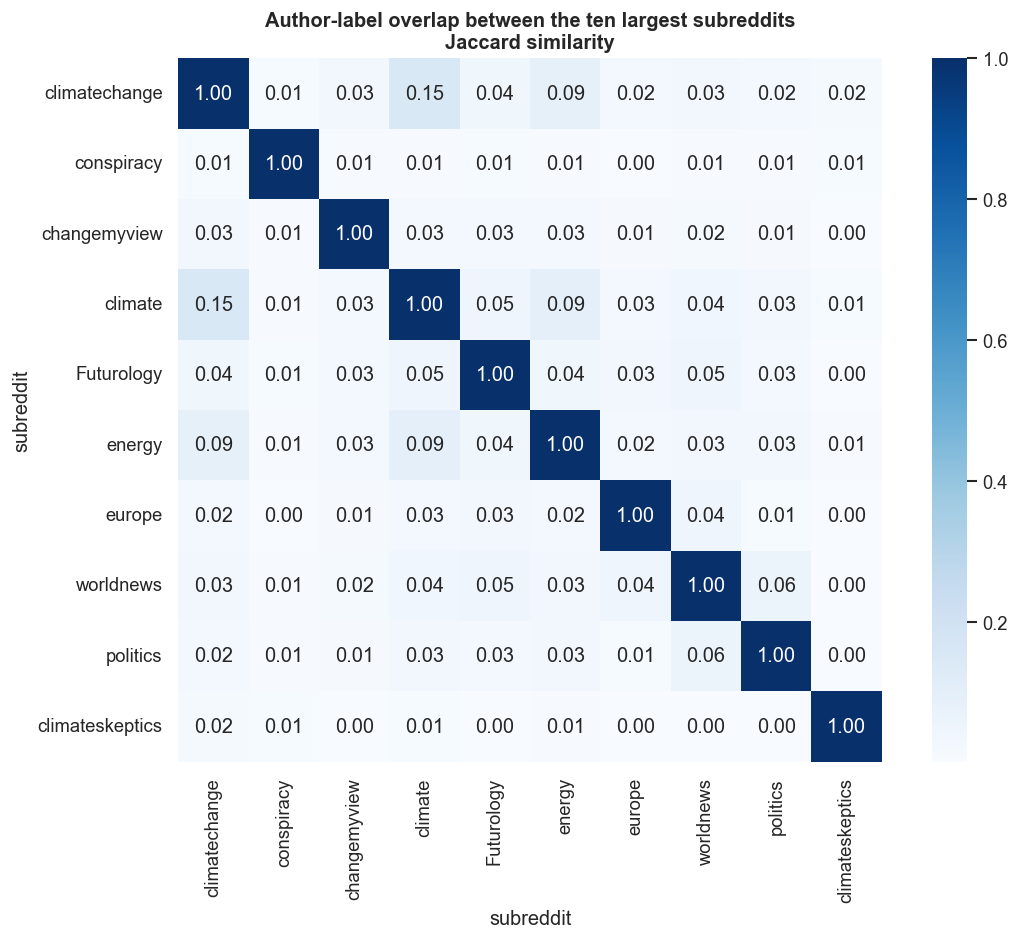

,,jaccard
subreddit,subreddit,
climatechange,climate,0.151046
climate,energy,0.094033
climatechange,energy,0.088564
worldnews,politics,0.059143
Futurology,worldnews,0.050064
climate,Futurology,0.046857
europe,worldnews,0.044611
climatechange,Futurology,0.043902
Futurology,energy,0.041884


In [15]:
top_communities = subreddit_counts.head(10).index
author_sets = {
    community: set(df.loc[valid_author_mask & df["subreddit"].eq(community), "author_name"])
    for community in top_communities
}
jaccard = pd.DataFrame(index=top_communities, columns=top_communities, dtype=float)
for a in top_communities:
    for b in top_communities:
        union = author_sets[a] | author_sets[b]
        jaccard.loc[a, b] = len(author_sets[a] & author_sets[b]) / len(union) if union else np.nan

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(jaccard, cmap="Blues", annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title("Author-label overlap between the ten largest subreddits\nJaccard similarity")
plt.tight_layout()
plt.show()

overlap_pairs = (
    jaccard.where(np.triu(np.ones(jaccard.shape), 1).astype(bool))
    .stack().sort_values(ascending=False).to_frame("jaccard")
)
overlap_pairs.head(15)

Jaccard=0 表示没有共享作者名称，1 表示作者集合完全相同。较高重叠意味着不同社区并非完全独立样本，RQ2 中应避免把同一批活跃用户误认为纯粹的社区差异。 / Jaccard 0 means no shared author labels and 1 means identical sets. Higher overlap shows that communities are not independent samples and may share active users.

The Jaccard similarities between major subreddits are modest, suggesting some user overlap but not complete independence.

## 16. 数值关系与层级限制 / Numeric Relationships and Level Limitations

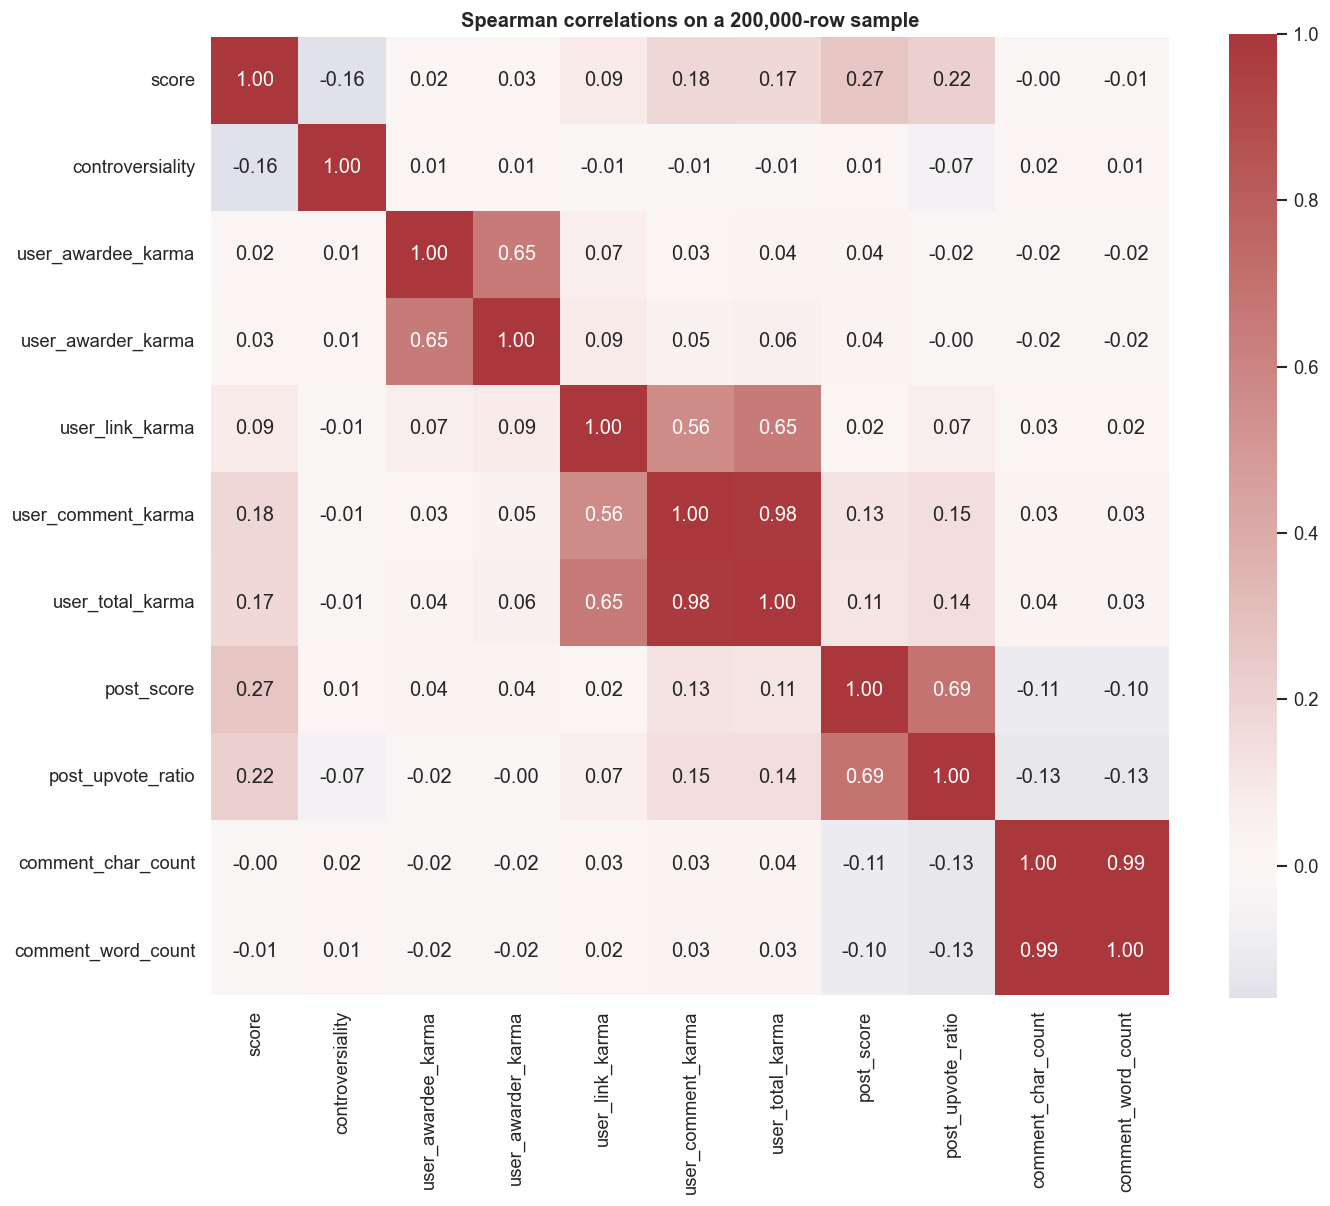

In [16]:
corr_columns = [
    "score", "controversiality", "user_awardee_karma", "user_awarder_karma",
    "user_link_karma", "user_comment_karma", "user_total_karma",
    "post_score", "post_upvote_ratio", "comment_char_count", "comment_word_count"
]
corr_sample = df[corr_columns].sample(min(200_000, len(df)), random_state=RANDOM_STATE)
corr = corr_sample.corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="vlag", center=0, annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title("Spearman correlations on a 200,000-row sample")
plt.tight_layout()
plt.show()

相关性只表示共同变化，不表示因果。用户 karma 和帖子指标在评论表中重复，因此严格推断需要分别建立用户级、帖子级或多层模型。 / Correlation shows co-movement, not causation. User karma and post measures repeat across comment rows, so formal inference requires user-level, post-level, or multilevel models.

## 17. 未来文本分析与社区比较准备度 / Readiness for Future Text and Community Analysis

In [17]:
readiness = (
    df.assign(eligible=eligible)
    .groupby("subreddit")
    .agg(
        cleaned_comments=("comment_id", "size"), eligible_comments=("eligible", "sum"),
        unique_posts=("post_id", "nunique"), named_authors=("author_name", lambda s: s[~s.astype(str).str.lower().isin(["[deleted]", "[removed]"])].nunique()),
        start=("created_time", "min"), end=("created_time", "max"),
        controversial_rate=("controversiality", "mean"), median_words=("comment_word_count", "median")
    )
)
readiness["eligible_share"] = readiness["eligible_comments"] / readiness["cleaned_comments"]
readiness["coverage_days"] = (readiness["end"] - readiness["start"]).dt.days
readiness.sort_values("eligible_comments", ascending=False)

,cleaned_comments,eligible_comments,unique_posts,named_authors,start,end,controversial_rate,median_words,eligible_share,coverage_days
subreddit,,,,,,,,,,
climatechange,245924,228177,6111,43616,2023-07-27 05:06:50,2026-09-18 06:06:12,0.019644,26.0,0.927835,1149
conspiracy,243531,217314,9191,54990,2023-11-11 13:00:03,2026-09-18 07:05:59,0.074155,20.0,0.892346,1041
changemyview,187214,183505,1870,42881,2023-11-19 18:30:03,2026-09-18 06:11:22,0.049943,48.0,0.980188,1033
climate,179027,162821,11963,36247,2023-10-12 13:12:57,2026-09-18 06:21:15,0.025080,21.0,0.909477,1071
Futurology,123555,120323,1684,45076,2023-09-20 22:30:32,2026-09-18 05:37:06,0.053968,31.0,0.973842,1093
energy,120913,112339,3055,29849,2023-09-21 23:57:41,2026-09-18 06:55:47,0.020891,23.0,0.929090,1092
europe,108501,100017,2152,39817,2023-11-08 11:24:17,2026-09-17 23:04:57,0.078939,21.0,0.921807,1044
worldnews,107716,98526,2382,55580,2023-11-14 15:27:34,2026-09-18 05:54:37,0.075411,19.0,0.914683,1038
politics,86339,79649,2069,39710,2023-11-14 20:45:49,2026-09-17 05:10:30,0.025064,19.0,0.922515,1037


这张表是下一步抽样与 RQ2 选社区的直接依据：同时检查有效文本数、帖子数、作者数、时间覆盖和争议率，而不是只看评论总量。 / This table directly supports sampling and RQ2 community selection by considering eligible text, posts, authors, time coverage, and controversiality rather than comment volume alone.

# 结论与新增方向 / Conclusions and Added Directions

在原扩展 EDA 基础上，本 notebook 新增：

- 清洗前后保留率与完整性审计；
- subreddit 集中度（HHI）；
- 争议率的 95% Wilson 区间；
- 正分、零分、负分构成；
- 帖子正文在不同社区的可用率；
- 词数和聚类准入比例；
- 月度覆盖热图；
- 用户与帖子贡献集中度、Lorenz 曲线和 Gini；
- 清洗后的重复文本核查；
- 社区之间的作者 Jaccard 重叠；
- 用于聚类和 RQ2 的综合准备度表。

下一步可将这些诊断与已经完成的聚类结果连接，重点检查：主题分布是否受到时间、热门帖子和高活跃用户影响。 / The next step is to connect these diagnostics to the completed clusters and test whether topic distributions are driven by time, large discussions, or highly active users.

# Define a common time window  
If comparing major large communities, it is recommended to start around 2023‑11‑19 and exclude September 2026, which is an incomplete month.

# Control post‑level and user‑level dominance effects  
Check why the top 20 largest discussions all come from energy; during clustering, consider sampling a fixed number of comments per post and conducting sensitivity analysis on highly active users.

# Determine the final text sample  
Use clean_text with at least five words; 

固定研究范围 / Fix the analytical scope
根据EDA，建议选择以下六个大型社区：
- climatechange
- climate
- energy
- Futurology
- conspiracy
- changemyview
选择理由：
- 都有超过11万条合格评论；
- 都有充足帖子和作者；
- 时间覆盖大致相近；
- 社区性质存在明显差异，适合RQ2比较。
Recommended subreddits:
- climatechange
- climate
- energy
- Futurology
- conspiracy
- changemyview
They contain sufficient eligible comments, posts, and authors, while representing different types of communities suitable for RQ2.
建议使用共同时间范围：
2023-11-19 至 2026-08-31
排除2026年9月，因为它是不完整月份。
Recommended common period:
19 November 2023 to 31 August 2026

文本数值化 / Numerical text representation
TF-IDF